# Pixels, sampling, and Fourier analysis

A digital image represents samples of a continuous field. Point sampling and area averaging are different operators. The Nyquist condition requires assumptions about band limits; sharper edges violate them. A Fourier spectrum shows which scales a blur removes.

**Objective:** explain why high-frequency fields can look low-frequency after coarse sampling.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


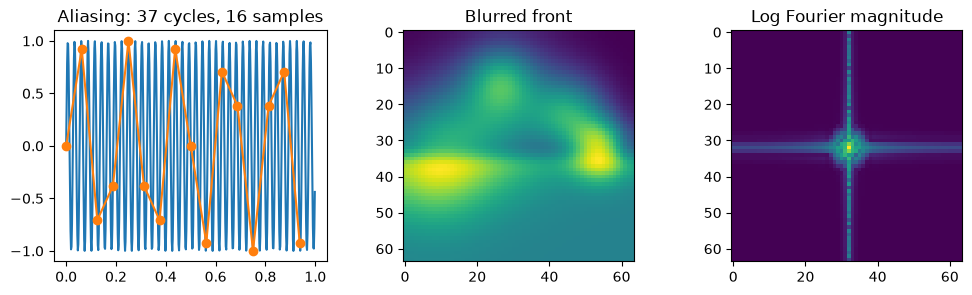

In [2]:
from scipy.ndimage import gaussian_filter
x=np.linspace(0,1,512,endpoint=False)
signal=np.sin(2*np.pi*37*x)
coarse=np.arange(0,512,32)
image=simulate(Grid((64,64)),seed=1,kind='front')
blur=gaussian_filter(image,2)
fig,axes=plt.subplots(1,3,figsize=(12,3))
axes[0].plot(x,signal); axes[0].plot(x[coarse],signal[coarse],'o-'); axes[0].set_title('Aliasing: 37 cycles, 16 samples')
axes[1].imshow(blur); axes[1].set_title('Blurred front')
axes[2].imshow(np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(image))))); axes[2].set_title('Log Fourier magnitude')
plt.show()
assert np.std(blur)<np.std(image)


**Exercise:** replace 37 cycles by 3, then 8. Change blur scale from 2 to 4. Explain both the frequency ambiguity and the loss of edge resolution. Why does a finite pixel footprint not simply behave as a point?

See [theory notes](../docs/theory.md) for assumptions and equations.